In [160]:
from utils import *
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import _t_sne
from tqdm import tqdm

tsne = TSNE(random_state=SEED, method='exact')
pca = PCA(n_components=2,random_state=SEED)

First, we show the poison point demonstration on a high-dimensional mixture of Gaussians.

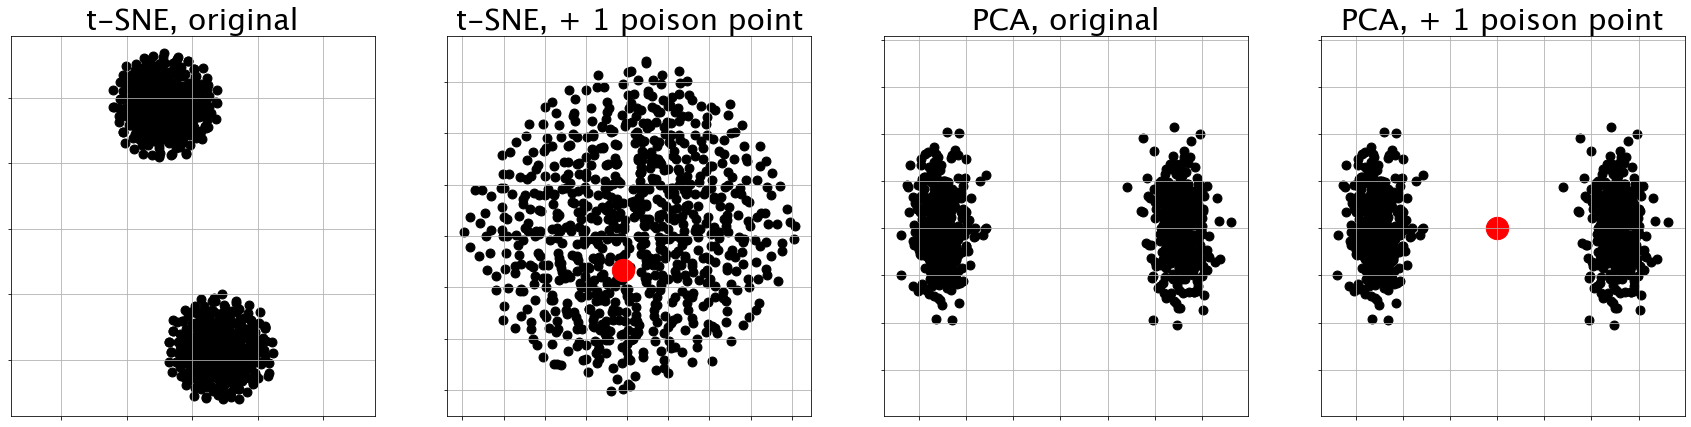

In [161]:
X = TwoGaussians(NumPointsInCluster=400, distance=1, dim=2000)
X1 = np.concatenate((X, np.array( [  np.mean(X, axis=0)  ])), axis=0)

X_tsne0 = tsne.fit_transform(X)
X_tsne1 = tsne.fit_transform(X1)

X_pca0 = pca.fit_transform(X)
X_pca1 = pca.fit_transform(X1)


fig, axs = plt.subplots(1,4, figsize=(30,7))
n = len(X)

for i in range(4):
    axs[i].grid('on')
    axs[i].axis('equal')
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])

axs[0].scatter(X_tsne0[:,0],X_tsne0[:,1],  s=80,color='black')
axs[0].set_title('t-SNE, original', fontsize=30)

axs[1].scatter(X_tsne1[:-1,0],X_tsne1[:-1,1], s=80, color='black')
axs[1].scatter(X_tsne1[-1,0],X_tsne1[-1,1],  s=500, color='red')
axs[1].set_title('t-SNE, + 1 poison point', fontsize=30)


axs[2].scatter(X_pca0[:,0],X_pca0[:,1],  s=80,color='black')
axs[2].set_title('PCA, original', fontsize=30)

axs[3].scatter(X_pca1[:-1,0],X_pca1[:-1,1], s=80, color='black')
axs[3].scatter(X_pca1[-1,0],X_pca1[-1,1],  s=500, color='red')
axs[3].set_title('PCA, + 1 poison point', fontsize=30)

total_pts = n*2  + 1
plt.savefig(f'visuals/2_adversarial/poison_point_{total_pts}.png', bbox_inches='tight' )

[t-SNE] Computed conditional probabilities for sample 800 / 800
[t-SNE] Mean sigma: 0.596332
[t-SNE] Computed conditional probabilities for sample 801 / 801
[t-SNE] Mean sigma: 1.120094


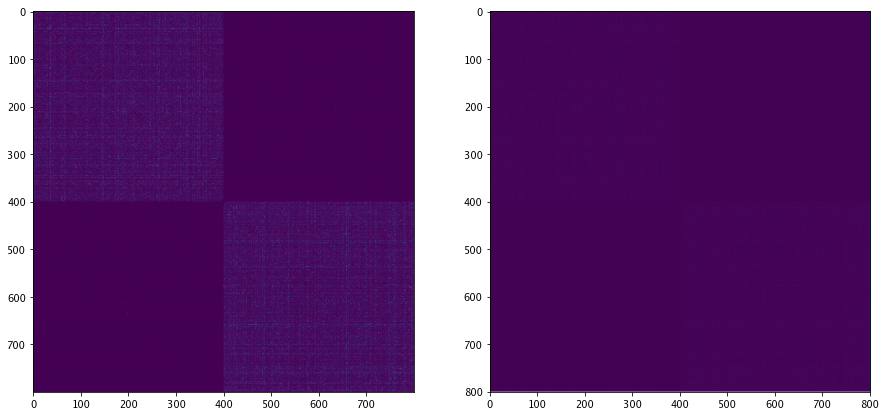

In [162]:
P = squareform(_t_sne._joint_probabilities(squareform(pdist(X, metric='sqeuclidean')), 300, 1))
P1 = squareform(_t_sne._joint_probabilities(squareform(pdist(X1, metric='sqeuclidean')), 300, 1))

fig, axs = plt.subplots(1,2, figsize=(15,7))
axs[0].imshow(P)
axs[1].imshow(P1)


Next, we show the poison point attack on a more ``contrived'' setting –– two clusters, simplex –– which seems to illustrate why the poison point attack hurts the mixture of high-dimensional Gaussians.

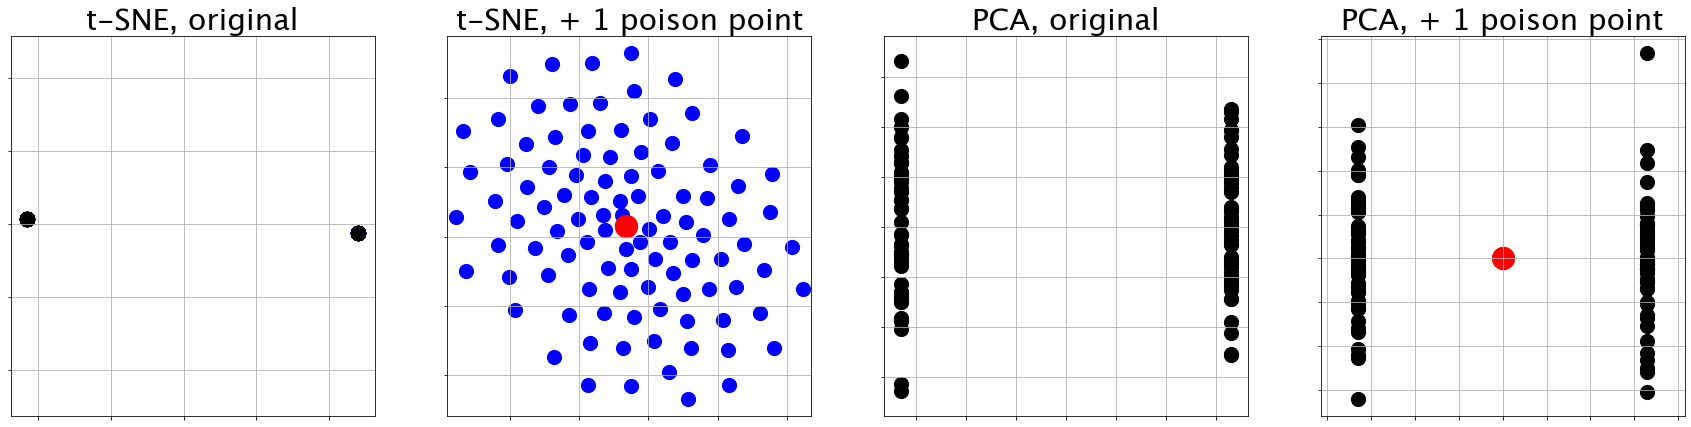

In [163]:
"""n = 200
X_contrived = []
for i in range(2*n):
    X_contrived.append(  np.eye(2*n+1)[i] )
for i in range(n):
    X_contrived[i] += np.array([0]*(2*n) + [1.0/n**2] )

X_contrived = np.array(X_contrived)
X1_contrived = np.concatenate((X_contrived, np.array( [  np.mean(X_contrived, axis=0) ] )), axis=0)
X1_contrived /= diam(X1_contrived)
"""
n = 50

X_contrived = np.array([ [0] for i in range(n) ] + [ [1] for i in range(n) ] )
X_contrived = impostor(X_contrived, 10)
X1_contrived = np.concatenate((X_contrived, np.array( [  np.mean(X_contrived, axis=0) ] )), axis=0)


X_tsne_contrived_0 = tsne.fit_transform(X_contrived)
X_tsne_contrived_1 = tsne.fit_transform(X1_contrived)

X_pca_contrived_0 = pca.fit_transform(X_contrived)
X_pca_contrived_1 = pca.fit_transform(X1_contrived)


fig, axs = plt.subplots(1,4, figsize=(30,7))
n = len(X)

for i in range(4):
    axs[i].grid('on')
    axs[i].axis('equal')
    #axs[i].set_aspect('equal')#, adjustable='box')
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])

axs[0].scatter(X_tsne_contrived_0[:n,0],X_tsne_contrived_0[:n,1], s=200, color='blue')
axs[0].scatter(X_tsne_contrived_0[n:-1,0],X_tsne_contrived_0[n:-1,1], s=200, color='green')
axs[0].scatter(X_tsne_contrived_0[:,0],X_tsne_contrived_0[:,1],  s=200,color='black')
axs[0].set_title('t-SNE, original', fontsize=30)

axs[1].scatter(X_tsne_contrived_1[:n,0],X_tsne_contrived_1[:n,1], s=200, color='blue')
axs[1].scatter(X_tsne_contrived_1[n:-1,0],X_tsne_contrived_1[n:-1,1], s=200, color='green')
axs[1].scatter(X_tsne_contrived_1[-1,0],X_tsne_contrived_1[-1,1],  s=500, color='red')
axs[1].set_title('t-SNE, + 1 poison point', fontsize=30)


axs[2].scatter(X_pca_contrived_0[:,0],X_pca_contrived_0[:,1],  s=200,color='black')
axs[2].set_title('PCA, original', fontsize=30)

axs[3].scatter(X_pca_contrived_1[:-1,0],X_pca_contrived_1[:-1,1], s=200, color='black')
axs[3].scatter(X_pca_contrived_1[-1,0],X_pca_contrived_1[-1,1],  s=500, color='red')
axs[3].set_title('PCA, + 1 poison point', fontsize=30)

total_pts = n*2  + 1
plt.savefig(f'visuals/2_adversarial/poison_point_contrived_{total_pts}.png', bbox_inches='tight' )

[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 0.034929
[t-SNE] Computed conditional probabilities for sample 101 / 101
[t-SNE] Mean sigma: 0.112528


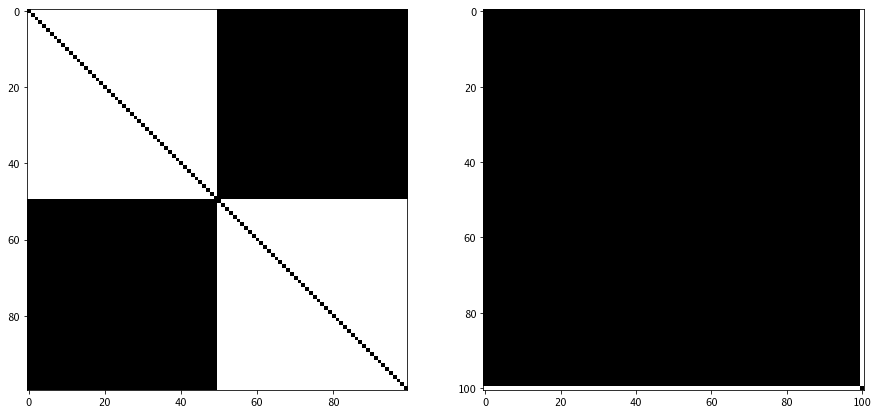

In [164]:
P = squareform(_t_sne._joint_probabilities(squareform(pdist(X_contrived, metric='sqeuclidean')), 1, 1))
P1 = squareform(_t_sne._joint_probabilities(squareform(pdist(X1_contrived, metric='sqeuclidean')), 1, 1))

fig, axs = plt.subplots(1,2, figsize=(15,7))
axs[0].imshow(P, cmap="gray")
axs[1].imshow(P1, cmap="gray")

plt.savefig('visuals/2_adversarial/poison_point.png', bbox_inches='tight' )


Random re-runs of t-SNE : the stability of the poison point attack

In [165]:
reruns = []
perps = []

for i in tqdm(range(8)):

    u = random.uniform(30, 100)
    tsne = TSNE(learning_rate=100,perplexity=u,method='exact',random_state=i)
    plot = tsne.fit_transform(X1) 
    reruns.append(plot)
    perps.append(u)

 62%|██████▎   | 5/8 [01:04<00:38, 12.94s/it]


KeyboardInterrupt: 

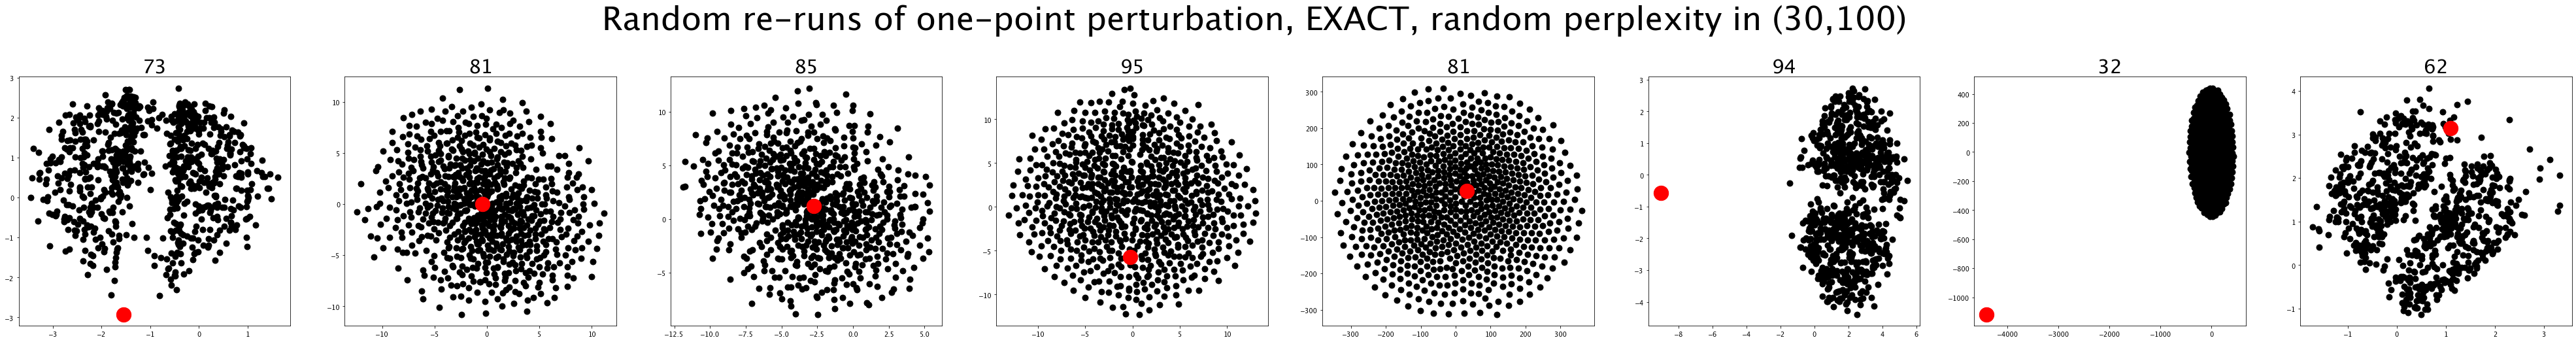

In [ ]:
fig, axs = plt.subplots(1,8, figsize=(70,7))
for i in range(8):

    axs[i].set_title(str(int(perps[i])), fontsize=30)
    axs[i].scatter(reruns[i][:-1,0],reruns[i][:-1,1], s=80, color='black')
    axs[i].scatter(reruns[i][-1,0],reruns[i][-1,1],  s=500, color='red')

plt.suptitle('Random re-runs of one-point perturbation, EXACT, random perplexity in (30,100)', fontsize=50,  y=1.1)
plt.savefig('visuals/2_adversarial/one_pt_perturb_exact_perplexitychanging.png')

(400, 399) (401, 399)
[t-SNE] Computed conditional probabilities for sample 400 / 400
[t-SNE] Mean sigma: 0.034929
[t-SNE] Computed conditional probabilities for sample 400 / 400
[t-SNE] Mean sigma: 0.051808
[t-SNE] Computed conditional probabilities for sample 401 / 401
[t-SNE] Mean sigma: 0.121498
[t-SNE] Computed conditional probabilities for sample 401 / 401
[t-SNE] Mean sigma: 0.172048


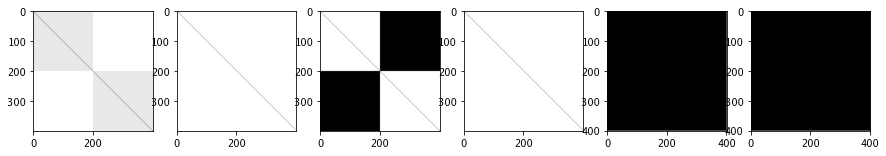

In [232]:
import numpy as np
from sklearn.decomposition import KernelPCA
from scipy.spatial.distance import pdist, cdist, squareform
from sklearn.manifold import _t_sne
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import _VALID_METRICS, pairwise_distances


SEED = 10

# D = block diagonal, diagonal n by n blocks have entries = 1 except along the exact diagonal where entry = 0, off diagonal n by n blocks have entries = 1+r
n = 200
r = 2

X1 = np.array([ [0] for i in range(n) ] + [ [1] for i in range(n) ] )
X1 = impostor(X1, 10)
X1_poison = np.concatenate((X1, np.array( [  np.mean(X1, axis=0) ] )), axis=0)

X2 = np.eye(2*n)
X2_poison = np.concatenate((X2, np.array( [  np.mean(X2, axis=0) ] )), axis=0)



"""D1 = np.zeros((2*n, 2*n))
D1[:n,:n] = np.ones((n,n)) - np.eye(n)
D1[n:,n:] = np.ones((n,n)) - np.eye(n)
D1[:n,n:] = (1 + r)*np.ones((n,n))
D1[n:,:n] = (1 + r)*np.ones((n,n))
"""

#D2 = np.ones((2*n,2*n)) - np.eye(2*n)



# get Euclidean realizabtion of D
#H = np.eye(2*n) - np.ones((2*n,2*n)) / (2*n)
#X1 = KernelPCA(n_components=2*n, kernel='precomputed', random_state=SEED).fit_transform( - H @ D1 @ H / 2.0 )
#X2 = KernelPCA(n_components=2*n, kernel='precomputed', random_state=SEED).fit_transform( - H @ D2 @ H / 2.0 )

#X1_poison = np.concatenate((X1, np.array( [  np.mean(X1, axis=0)  ])), axis=0)
#X2_poison = np.concatenate((X2, np.array( [  np.mean(X2, axis=0)  ])), axis=0)

print(X1.shape, X1_poison.shape)

P1 = squareform(_t_sne._joint_probabilities(squareform(pdist(X1, metric='sqeuclidean')), 1, 1))
P2 = squareform(_t_sne._joint_probabilities(squareform(pdist(X2, metric='sqeuclidean')), 1, 1))
P1_poison = squareform(_t_sne._joint_probabilities(squareform(pdist(X1_poison, metric='sqeuclidean')), 1, 1))
P2_poison = squareform(_t_sne._joint_probabilities(squareform(pdist(X2_poison, metric='sqeuclidean')), 1, 1))

fig, axs = plt.subplots(1,6, figsize=(15,15))
axs[0].imshow(squareform(pdist(X1, metric='sqeuclidean')), cmap='gray' )
axs[1].imshow(squareform(pdist(X2, metric='sqeuclidean')), cmap='gray' )
axs[2].imshow(P1, cmap="gray")
axs[3].imshow(P2, cmap="gray")
axs[4].imshow(P1_poison, cmap="gray")
axs[5].imshow(P2_poison, cmap="gray")


Text(0.5, 1.1, 't-SNE on X0 vs X1, with and without poison point')

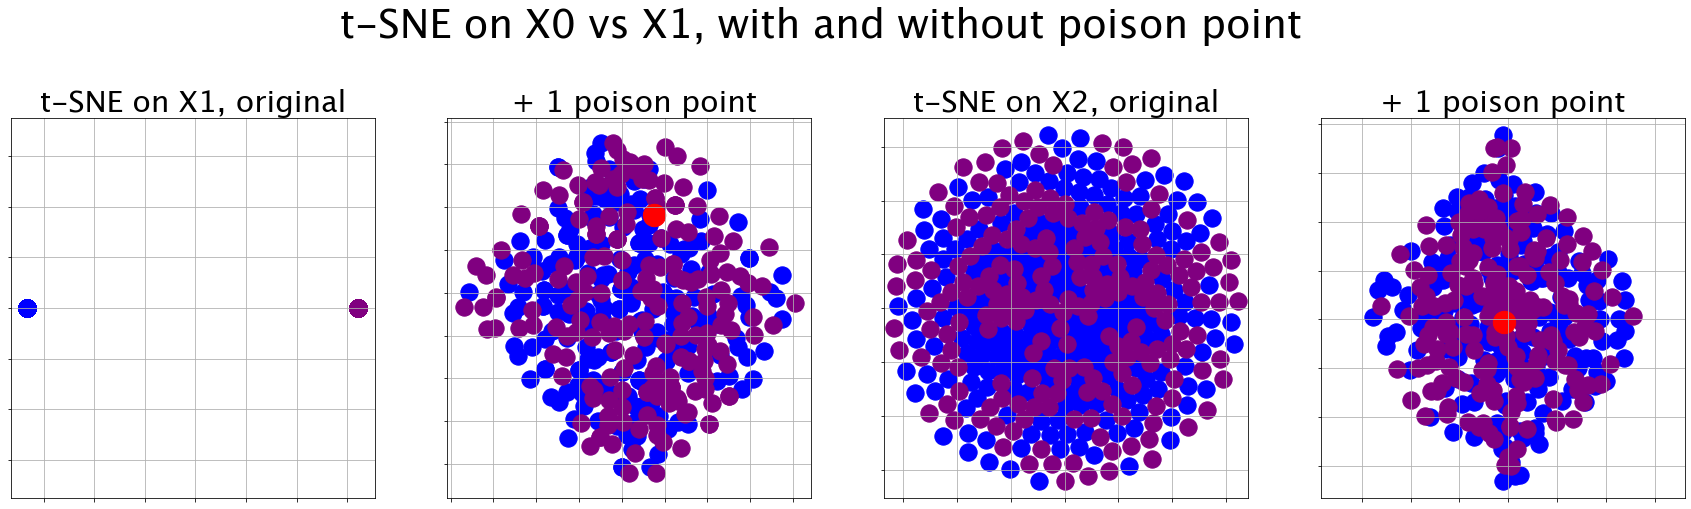

In [ ]:
from sklearn.manifold import TSNE
# run tSNE on D1 vs D2
tsne = TSNE(random_state=SEED,perplexity=1, method='exact')#, metric='precomputed')

X1_tsne = tsne.fit_transform(X1)
X2_tsne = tsne.fit_transform(X2)
X1_poison_tsne = tsne.fit_transform(X1_poison)
X2_poison_tsne = tsne.fit_transform(X2_poison)

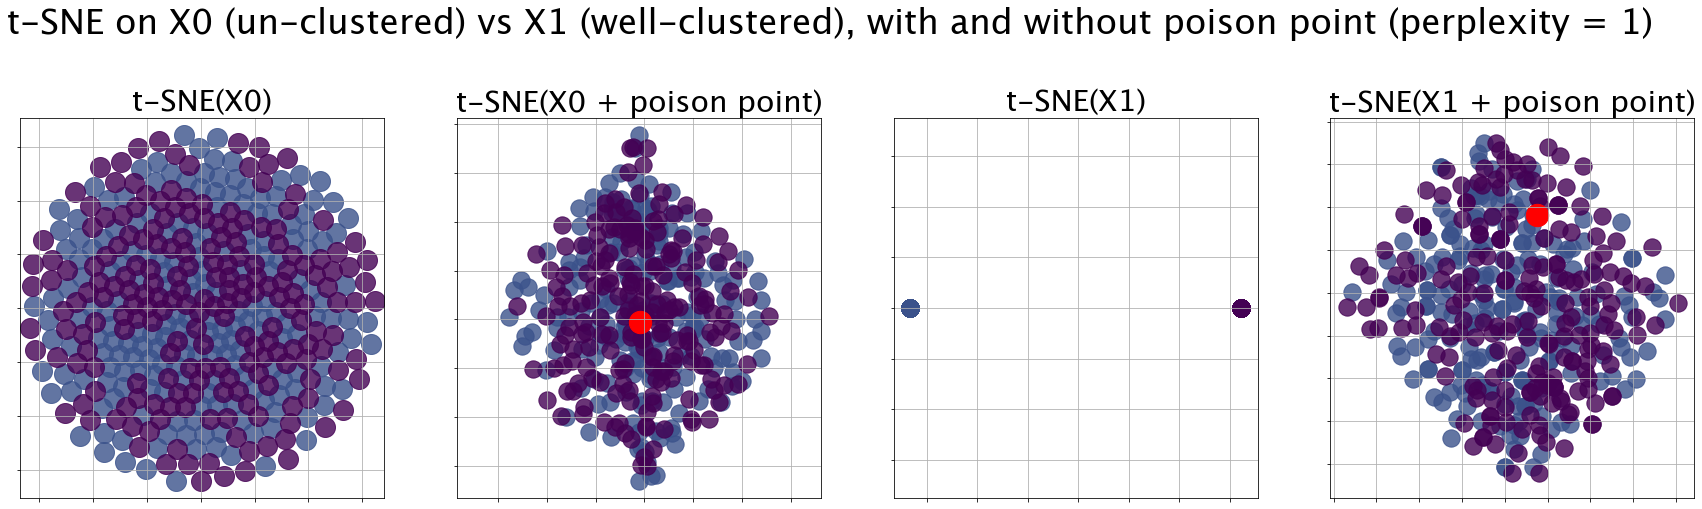

In [269]:
my_colors = {
    1:"#3B528B",   # red
    2:"#FDE725",   # blue
    3:"#440154",   # green
    4:'black',
    5:'black'
}

fig, axs = plt.subplots(1,4, figsize=(30,7))
for i in range(4):
    axs[i].grid('on')
    axs[i].axis('equal')
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
axs[2].scatter(X1_tsne[:n,0],X1_tsne[:n,1], s=300, color=my_colors[1], alpha=0.8)
axs[2].scatter(X1_tsne[n:,0],X1_tsne[n:,1], s=300, color=my_colors[3] , alpha=0.8)
axs[2].set_title('t-SNE(X1)', fontsize=30)
axs[3].scatter(X1_poison_tsne[:n,0],X1_poison_tsne[:n,1], s=300, color=my_colors[1], alpha=0.8)
axs[3].scatter(X1_poison_tsne[n:-1,0],X1_poison_tsne[n:-1,1], s=300, color=my_colors[3], alpha=0.8)
axs[3].scatter(X1_poison_tsne[-1,0],X1_poison_tsne[-1,1],  s=500, color='red')
axs[3].set_title('t-SNE(X1 + poison point)', fontsize=30)
axs[0].scatter(X2_tsne[:n,0],X2_tsne[:n,1], s=400, color=my_colors[1], alpha=0.8)
axs[0].scatter(X2_tsne[n:,0],X2_tsne[n:,1], s=400, color=my_colors[3], alpha=0.8)
axs[0].set_title('t-SNE(X0)', fontsize=30)
axs[1].scatter(X2_poison_tsne[:n,0],X2_poison_tsne[:n,1], s=300, color=my_colors[1], alpha=0.8)
axs[1].scatter(X2_poison_tsne[n:-1,0],X2_poison_tsne[n:-1,1], s=300, color=my_colors[3], alpha=0.8)
axs[1].scatter(X2_poison_tsne[-1,0],X2_poison_tsne[-1,1],  s=500, color='red')
axs[1].set_title('t-SNE(X0 + poison point)', fontsize=30)
plt.suptitle('t-SNE on X0 (un-clustered) vs X1 (well-clustered), with and without poison point (perplexity = 1)', fontsize=35, y=1.1)
plt.savefig('visuals/2_poison_point/thm7.png', bbox_inches='tight' )